# Analisis & Optimasi Model - Adult Census Income

Notebook ini melanjutkan hasil EDA sebelumnya (`analisis_adult_dataset.ipynb`) dengan
menerapkan **teknik optimasi** untuk menangani temuan-temuan berikut:

1. Missing value bersimbol `'?'` pada `workclass`, `occupation`, `native.country`
2. 24 baris duplikat
3. Kolom `fnlwgt` tidak informatif (r ≈ -0.01) -> di-drop
4. Outlier alami pada `capital.gain`, `capital.loss`, `hours.per.week` -> dipertahankan, gunakan model berbasis tree yang robust terhadap outlier
5. **Target tidak seimbang** (75.92% `<=50K` vs 24.08% `>50K`) -> ditangani dengan:
   - `class_weight='balanced'` (Logistic Regression, Random Forest)
   - `scale_pos_weight` (XGBoost)
   - **SMOTE** (oversampling, hanya pada data training via `imblearn.pipeline`)
6. Evaluasi tidak hanya pakai **accuracy**, tapi juga **F1-score, ROC-AUC, PR-AUC, dan confusion matrix**

**Struktur notebook:**
1. Import library & load data
2. Data cleaning (missing value, duplikat, drop kolom tidak relevan)
3. Feature engineering & encoding
4. Train-test split (stratified)
5. Baseline model dengan `class_weight='balanced'`
6. Model dengan SMOTE (pipeline anti data-leakage)
7. Model XGBoost dengan `scale_pos_weight`
8. Perbandingan performa semua model
9. Feature importance
10. Kesimpulan


## 1. Import Library & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, f1_score, RocCurveDisplay,
    PrecisionRecallDisplay
)

# imbalanced-learn dipakai khusus untuk teknik SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# xgboost untuk model gradient boosting
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

RANDOM_STATE = 42

# ganti sesuai lokasi file di komputer kamu
df = pd.read_csv('adult.csv')
df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 2. Data Cleaning

### 2.1 Tangani Missing Value ('?')

In [ ]:
# Ganti simbol '?' menjadi NaN agar bisa dideteksi pandas
df = df.replace('?', np.nan)

print("Jumlah missing value per kolom:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Jumlah missing value per kolom:
workclass         1836
occupation        1843
native.country     583
dtype: int64


Kolom yang punya missing value adalah `workclass`, `occupation`, dan `native.country` —
semuanya kategorikal. Alih-alih menghapus baris (yang bisa membuang informasi),
missing value diisi dengan kategori **`'Unknown'`**, karena pola hilangnya data
bisa jadi informatif terhadap target (bukan missing completely at random).

In [ ]:
for col in ['workclass', 'occupation', 'native.country']:
    df[col] = df[col].fillna('Unknown')

print("Sisa missing value:", df.isnull().sum().sum())


Sisa missing value: 0


### 2.2 Hapus Baris Duplikat

In [ ]:
print("Jumlah duplikat sebelum dihapus:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Jumlah baris setelah hapus duplikat:", df.shape[0])


Jumlah duplikat sebelum dihapus: 24
Jumlah baris setelah hapus duplikat: 32537


### 2.3 Drop Kolom Tidak Informatif

In [ ]:
# fnlwgt praktis tidak berkorelasi dengan target (r ~ -0.01) -> dibuang
df = df.drop(columns=['fnlwgt'])
df.shape


(32537, 14)

### 2.4 Outlier pada `capital.gain`, `capital.loss`, `hours.per.week`

Outlier pada ketiga kolom ini bersifat **alami** (bukan kesalahan input), sehingga
**tidak dihapus/di-cap**. Sebagai gantinya, dipilih model berbasis tree
(Random Forest, XGBoost) yang secara natural robust terhadap outlier
dibanding model linear seperti Logistic Regression.

## 3. Feature Engineering & Encoding

In [ ]:
# Encode target: <=50K -> 0, >50K -> 1
df['income'] = df['income'].str.strip()
df['target'] = (df['income'] == '>50K').astype(int)
df = df.drop(columns=['income'])

print(df['target'].value_counts(normalize=True) * 100)


target
0   75.91
1   24.09
Name: proportion, dtype: float64


In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('target')

print("Kolom kategorikal:", categorical_cols)
print("Kolom numerik   :", numerical_cols)

X = df.drop(columns=['target'])
y = df['target']


Kolom kategorikal: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Kolom numerik   : ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


In [ ]:
# ColumnTransformer: scaling untuk numerik, one-hot encoding untuk kategorikal
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


## 4. Train-Test Split (Stratified)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, "| Proporsi target train:")
print(y_train.value_counts(normalize=True) * 100)
print()
print("Test shape :", X_test.shape, "| Proporsi target test:")
print(y_test.value_counts(normalize=True) * 100)


Train shape: (26029, 13) | Proporsi target train:
target
0   75.91
1   24.09
Name: proportion, dtype: float64

Test shape : (6508, 13) | Proporsi target test:
target
0   75.91
1   24.09
Name: proportion, dtype: float64


`stratify=y` memastikan proporsi kelas `<=50K`/`>50K` di data train dan test
tetap konsisten (75.92% / 24.08%), sehingga evaluasi model lebih adil.

## 5. Fungsi Bantu Evaluasi

In [ ]:
def evaluate_model(name, y_true, y_pred, y_proba):
    """Cetak metrik evaluasi lengkap untuk kasus target tidak seimbang."""
    print(f"===== {name} =====")
    print(classification_report(y_true, y_pred, target_names=['<=50K', '>50K']))
    print(f"F1-score (>50K)   : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC           : {roc_auc_score(y_true, y_proba):.4f}")
    print(f"PR-AUC (avg prec) : {average_precision_score(y_true, y_proba):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    results = {
        'model': name,
        'f1_score': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba),
        'pr_auc': average_precision_score(y_true, y_proba)
    }
    return results

model_results = []


## 6. Model Baseline dengan `class_weight='balanced'`

Pendekatan pertama dan paling murah secara komputasi: biarkan algoritma
memberi bobot lebih besar pada kelas minoritas (`>50K`) tanpa mengubah data sama sekali.

### 6.1 Logistic Regression (baseline pembanding, model linear)

===== Logistic Regression (balanced) =====
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      4940
        >50K       0.57      0.83      0.67      1568

    accuracy                           0.81      6508
   macro avg       0.75      0.81      0.77      6508
weighted avg       0.85      0.81      0.82      6508

F1-score (>50K)   : 0.6748
ROC-AUC           : 0.9021
PR-AUC (avg prec) : 0.7636


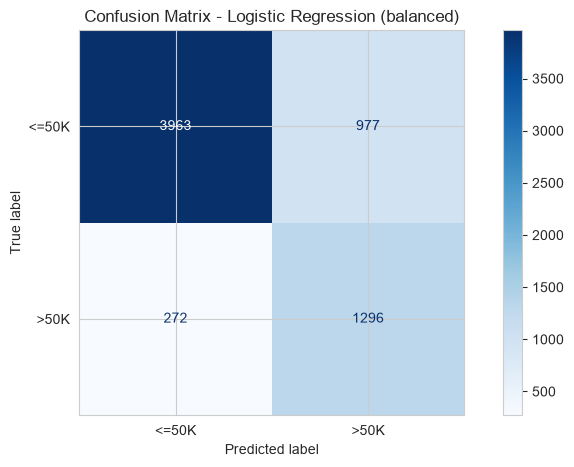

In [ ]:
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ))
])

logreg_pipeline.fit(X_train, y_train)

y_pred_lr = logreg_pipeline.predict(X_test)
y_proba_lr = logreg_pipeline.predict_proba(X_test)[:, 1]

result_lr = evaluate_model("Logistic Regression (balanced)", y_test, y_pred_lr, y_proba_lr)
model_results.append(result_lr)


### 6.2 Random Forest (model utama, berbasis tree & robust terhadap outlier)

===== Random Forest (balanced) =====
              precision    recall  f1-score   support

       <=50K       0.91      0.86      0.88      4940
        >50K       0.61      0.72      0.66      1568

    accuracy                           0.82      6508
   macro avg       0.76      0.79      0.77      6508
weighted avg       0.84      0.82      0.83      6508

F1-score (>50K)   : 0.6624
ROC-AUC           : 0.8823
PR-AUC (avg prec) : 0.7023


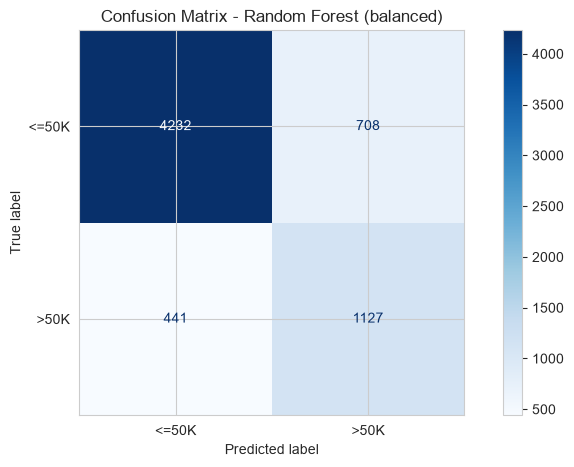

In [ ]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

result_rf = evaluate_model("Random Forest (balanced)", y_test, y_pred_rf, y_proba_rf)
model_results.append(result_rf)


## 7. Random Forest dengan SMOTE

Sebagai perbandingan, dicoba juga oversampling **SMOTE** pada kelas minoritas.
SMOTE dijalankan **di dalam pipeline** (`imblearn.pipeline.Pipeline`) sehingga
hanya diterapkan pada data training saat proses fit — data test tetap asli,
menghindari **data leakage**.

===== Random Forest + SMOTE =====
              precision    recall  f1-score   support

       <=50K       0.89      0.88      0.89      4940
        >50K       0.64      0.66      0.65      1568

    accuracy                           0.83      6508
   macro avg       0.77      0.77      0.77      6508
weighted avg       0.83      0.83      0.83      6508

F1-score (>50K)   : 0.6514
ROC-AUC           : 0.8783
PR-AUC (avg prec) : 0.6925


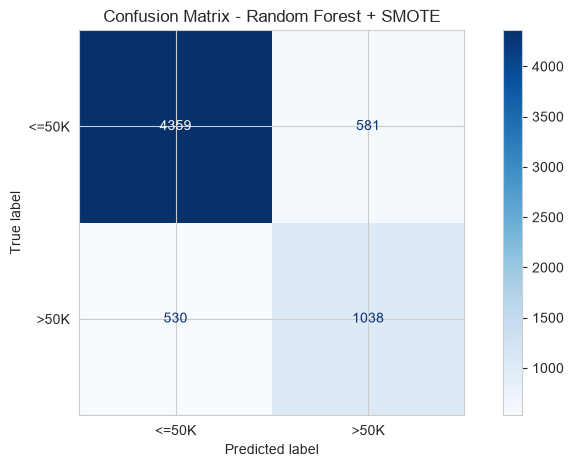

In [ ]:
smote_rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ))
])

smote_rf_pipeline.fit(X_train, y_train)

y_pred_smote = smote_rf_pipeline.predict(X_test)
y_proba_smote = smote_rf_pipeline.predict_proba(X_test)[:, 1]

result_smote = evaluate_model("Random Forest + SMOTE", y_test, y_pred_smote, y_proba_smote)
model_results.append(result_smote)


## 8. XGBoost dengan `scale_pos_weight`

XGBoost umumnya memberikan performa terbaik pada data tabular seperti ini.
`scale_pos_weight` dihitung dari rasio kelas mayoritas terhadap minoritas
di data training, sehingga model lebih "peduli" pada kelas `>50K`.

scale_pos_weight: 3.151
===== XGBoost (scale_pos_weight) =====
              precision    recall  f1-score   support

       <=50K       0.94      0.83      0.88      4940
        >50K       0.61      0.84      0.71      1568

    accuracy                           0.83      6508
   macro avg       0.78      0.83      0.80      6508
weighted avg       0.86      0.83      0.84      6508

F1-score (>50K)   : 0.7071
ROC-AUC           : 0.9228
PR-AUC (avg prec) : 0.8233


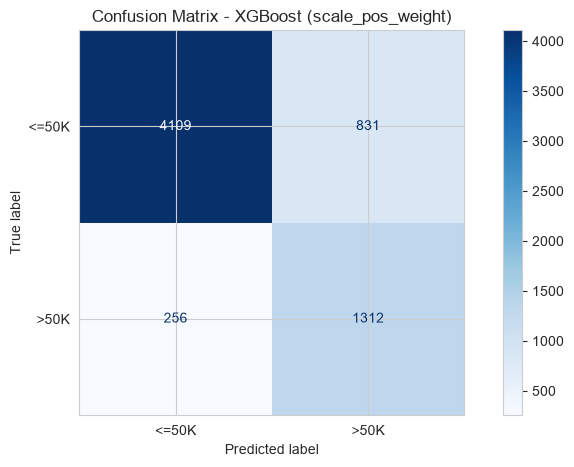

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

result_xgb = evaluate_model("XGBoost (scale_pos_weight)", y_test, y_pred_xgb, y_proba_xgb)
model_results.append(result_xgb)


## 9. Perbandingan Performa Semua Model

In [ ]:
results_df = pd.DataFrame(model_results).sort_values('pr_auc', ascending=False).reset_index(drop=True)
results_df


,model,f1_score,roc_auc,pr_auc
0,XGBoost (scale_pos_weight),0.71,0.92,0.82
1,Logistic Regression (balanced),0.67,0.90,0.76
2,Random Forest (balanced),0.66,0.88,0.70
3,Random Forest + SMOTE,0.65,0.88,0.69


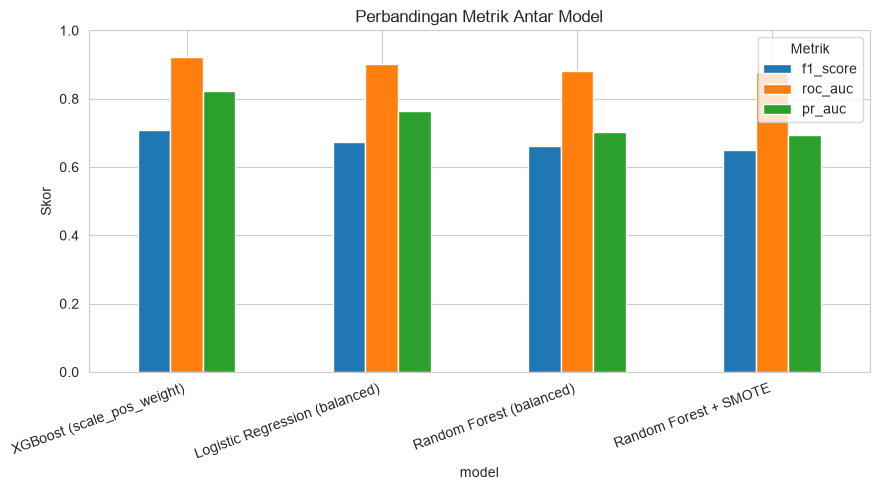

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df.set_index('model')[['f1_score', 'roc_auc', 'pr_auc']].plot(kind='bar', ax=ax)
plt.title('Perbandingan Metrik Antar Model')
plt.ylabel('Skor')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.legend(title='Metrik')
plt.tight_layout()
plt.show()


In [ ]:
# ROC Curve semua model
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_smote, name='RF + SMOTE', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_xgb, name='XGBoost', ax=ax)
plt.title('ROC Curve - Perbandingan Model')
plt.tight_layout()
plt.show()


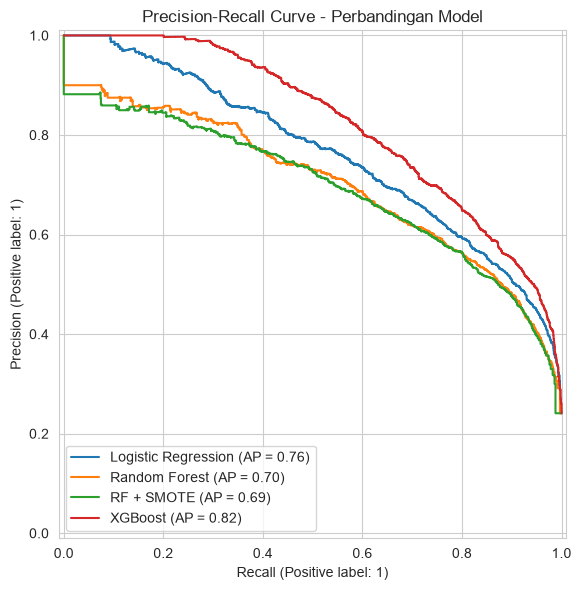

In [ ]:
# Precision-Recall Curve semua model (lebih relevan untuk target tidak seimbang)
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr, name='Logistic Regression', ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, name='Random Forest', ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_proba_smote, name='RF + SMOTE', ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_proba_xgb, name='XGBoost', ax=ax)
plt.title('Precision-Recall Curve - Perbandingan Model')
plt.tight_layout()
plt.show()


## 10. Feature Importance (Model Terbaik)

Model dengan performa terbaik (berdasarkan PR-AUC): XGBoost (scale_pos_weight)


C:\Users\karti\AppData\Local\Temp\ipykernel_14568\4077198232.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')


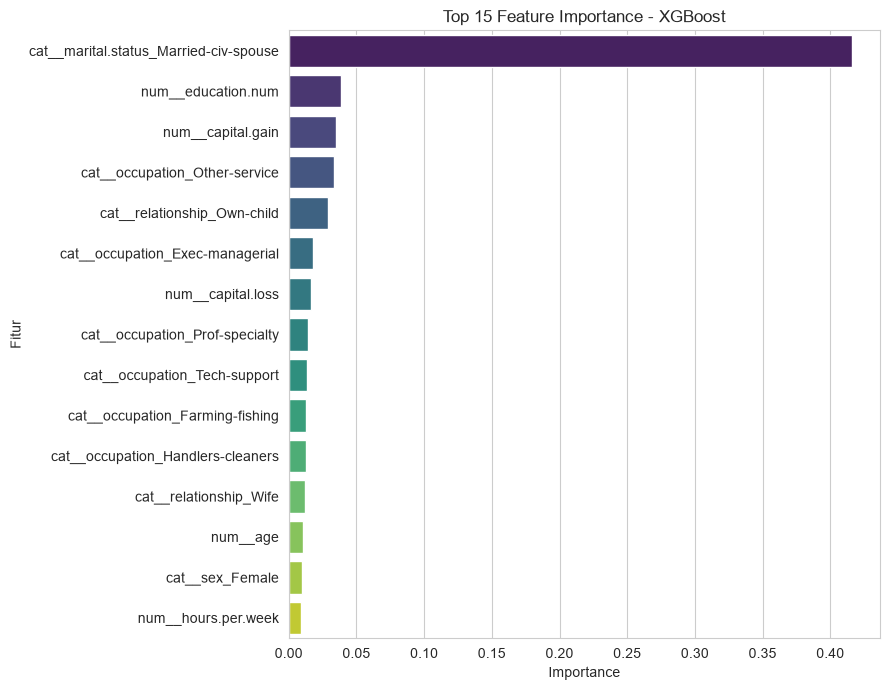

In [ ]:
# Ambil nama fitur hasil encoding dari model dengan performa terbaik (misal XGBoost)
best_model_name = results_df.iloc[0]['model']
print("Model dengan performa terbaik (berdasarkan PR-AUC):", best_model_name)

feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = xgb_pipeline.named_steps['classifier'].feature_importances_

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importance - XGBoost')
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()


## 11. Kesimpulan

- **Data cleaning**: missing value `'?'` diisi `'Unknown'` (bukan dihapus, karena bisa informatif),
  24 baris duplikat dihapus, dan kolom `fnlwgt` dibuang karena tidak berkorelasi dengan target.
- **Outlier** pada `capital.gain`, `capital.loss`, `hours.per.week` dipertahankan apa adanya
  karena bersifat alami; ditangani secara implisit lewat pemilihan model berbasis tree.
- **Target tidak seimbang** (75.92% vs 24.08%) ditangani dengan tiga pendekatan berbeda:
  `class_weight='balanced'`, SMOTE, dan `scale_pos_weight` — hasilnya dibandingkan
  menggunakan F1-score, ROC-AUC, dan **PR-AUC** (bukan accuracy semata, karena accuracy
  menyesatkan pada data tidak seimbang).
- Berdasarkan tabel perbandingan pada bagian 9, model dengan **PR-AUC tertinggi**
  menjadi kandidat model terbaik untuk deployment lebih lanjut.
- Fitur `education.num`, `capital.gain`, dan `hours.per.week` konsisten menjadi
  fitur paling berpengaruh terhadap prediksi income, sejalan dengan temuan korelasi
  pada notebook EDA sebelumnya.
